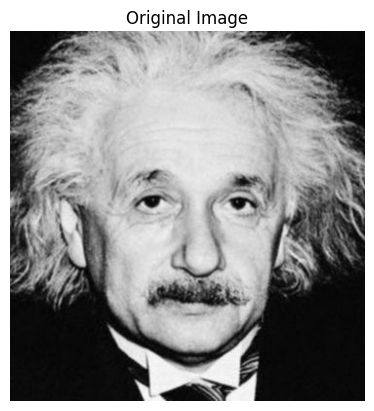

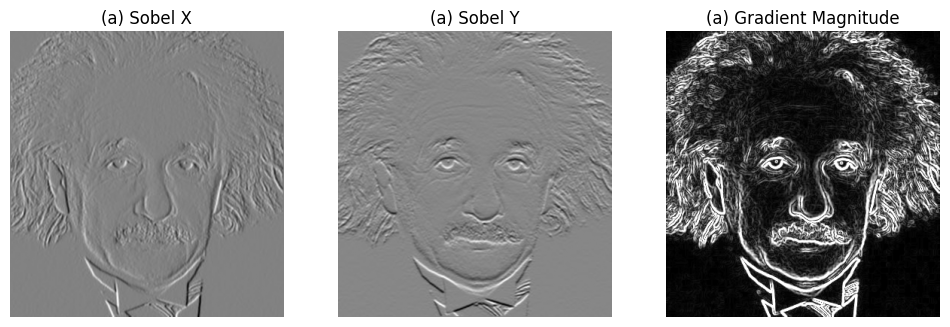

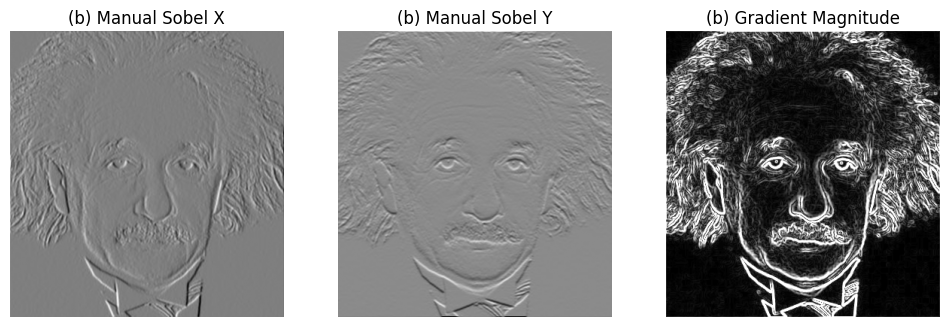

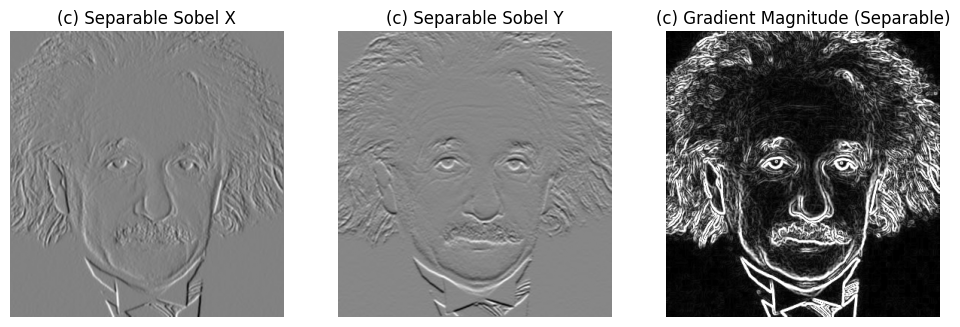

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

fname = '/content/sample_data/einstein.png'
img = cv2.imread(fname, cv2.IMREAD_GRAYSCALE)

plt.figure()
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]], dtype=np.float32)

sobel_y = np.array([[-1,-2,-1],
                    [ 0, 0, 0],
                    [ 1, 2, 1]], dtype=np.float32)

grad_x = cv2.filter2D(img, cv2.CV_64F, sobel_x)
grad_y = cv2.filter2D(img, cv2.CV_64F, sobel_y)

mag_a = np.sqrt(grad_x**2 + grad_y**2)
mag_a = cv2.convertScaleAbs(mag_a)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(grad_x, cmap="gray"); plt.title("(a) Sobel X"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(grad_y, cmap="gray"); plt.title("(a) Sobel Y"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_a, cmap="gray"); plt.title("(a) Gradient Magnitude"); plt.axis("off")
plt.show()


def conv2d(image, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh//2, kw//2
    padded = np.pad(image, ((pad_h,pad_h),(pad_w,pad_w)), mode='constant')
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i,j] = np.sum(region * kernel)
    return output

grad_x_b = conv2d(img, sobel_x)
grad_y_b = conv2d(img, sobel_y)
mag_b = np.sqrt(grad_x_b**2 + grad_y_b**2)
mag_b = cv2.convertScaleAbs(mag_b)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(grad_x_b, cmap="gray"); plt.title("(b) Manual Sobel X"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(grad_y_b, cmap="gray"); plt.title("(b) Manual Sobel Y"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_b, cmap="gray"); plt.title("(b) Gradient Magnitude"); plt.axis("off")
plt.show()



dx = np.array([[-1, 0, 1]], dtype=np.float32)
dy = np.array([[1],[2],[1]], dtype=np.float32)

sobel_x_sep = cv2.filter2D(img, cv2.CV_64F, dx)
sobel_x_sep = cv2.filter2D(sobel_x_sep, cv2.CV_64F, dy)

dy_d = np.array([[-1],[0],[1]], dtype=np.float32)
dx_s = np.array([[1,2,1]], dtype=np.float32)

sobel_y_sep = cv2.filter2D(img, cv2.CV_64F, dy_d)
sobel_y_sep = cv2.filter2D(sobel_y_sep, cv2.CV_64F, dx_s)

mag_c = np.sqrt(sobel_x_sep**2 + sobel_y_sep**2)
mag_c = cv2.convertScaleAbs(mag_c)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(sobel_x_sep, cmap="gray"); plt.title("(c) Separable Sobel X"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(sobel_y_sep, cmap="gray"); plt.title("(c) Separable Sobel Y"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_c, cmap="gray"); plt.title("(c) Gradient Magnitude (Separable)"); plt.axis("off")
plt.show()

